Важность признаков в предсказании: permutation importance, SHAP, LIME.

Три метода отвечают на разные вопросы:

- **Permutation importance** — «насколько хуже станут предсказания на новых данных, если признак испортить?»
- **SHAP** — «как модель фактически пришла к предсказанию?» Работает и глобально (средний вклад признака), и локально (разложение одного предсказания).
- **LIME** — «объясни один конкретный случай простыми правилами» — для показа человеку без ML-фона.

Модель одна — Random Forest т.к. довольно неприхотливая и относительно простая

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('Titanic-Dataset.csv')

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['TicketGroupSize'] = df.groupby('Ticket')['Ticket'].transform('count')
df['FarePerPersonLog'] = np.log1p(df['Fare'] / df['TicketGroupSize'])

df_ml = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
X = df_ml[['Pclass', 'Age', 'FarePerPersonLog', 'FamilySize', 'Sex_male', 'Embarked_Q', 'Embarked_S']]
y = df_ml['Survived']
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
proba = rf.predict_proba(X_test)[:, 1]  # вероятность "выжил" для каждого пассажира теста
print("Модель обучена. Размер теста:", len(X_test))

Модель обучена. Размер теста: 179


**1. Permutation importance.** Перемешиваем значения одного признака между строками теста (связь с target разрушена, распределение сохранено) и смотрим, насколько просело качество. Просело сильно — признак важен; не просело — модель без него не хуже.

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, scoring="f1")

perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values()
fig = px.bar(
    perm_imp, orientation="h",
    text_auto=".3f",
    color_discrete_sequence=["#4C78A8"],
    template="plotly_white", height=350,
    title="Permutation importance на тесте (падение F1)",
    labels={"value": "Среднее падение F1 при перемешивании", "index": "Признак"}
)
fig.update_layout(title_x=0.5, showlegend=False)
fig.show()

print("Признаки с важностью около нуля модель не использует для обобщения — на выброс. (Стоит ли сравнивать со встроенной важностью в test2: там шум получал вес).")

Признаки с важностью около нуля модель не использует для обобщения —
кандидаты на выброс (сравни со встроенной важностью в test2: там шум получал вес).


**2. SHAP глобально.** SHAP раскладывает каждое предсказание на вклады признаков: базовая вероятность + сумма вкладов = предсказание модели для пассажира. Усредняем вклад по всем пассажирам теста — получаем глобальную важность в единицах вероятности.

In [11]:
import shap

explainer = shap.TreeExplainer(rf)
sv = np.array(explainer.shap_values(X_test))

# У бинарной классификации shap возвращает вклады для двух классов — берём класс «выжил»
shap_values = sv[:, :, 1] if sv.ndim == 3 else sv
base_value = float(np.array(explainer.expected_value).ravel()[-1])

shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values()
fig = px.bar(
    shap_imp, orientation="h",
    text_auto=".3f",
    color_discrete_sequence=["#4C78A8"],
    template="plotly_white", height=350,
    title="SHAP: средний вклад признака в вероятность выживания",
    labels={"value": "Средний вклад, в единицах вероятности", "index": "Признак"}
)
fig.update_layout(title_x=0.5, showlegend=False)
fig.show()

print(f"Базовая вероятность (средняя по обучению): {base_value:.2f}")
print("Важно: SHAP объясняет модель, а не реальность — если модель переобучилась на шум, то SHAP честно покажет, что она им пользуется.")

Базовая вероятность (средняя по обучению): 0.39
Важно: SHAP объясняет модель, а не реальность — если модель переобучилась на шум, то SHAP честно покажет, что она им пользуется.


**3. SHAP локально.** Разложение одного предсказания: почему именно этому пассажиру модель дала такую вероятность. В shap есть свои графики :)

Пассажир #853: предсказание 0.95, на самом деле выжил


,Pclass,Age,FarePerPersonLog,FamilySize,Sex_male,Embarked_Q,Embarked_S
853,1,16.0,3.69883,2,False,False,True


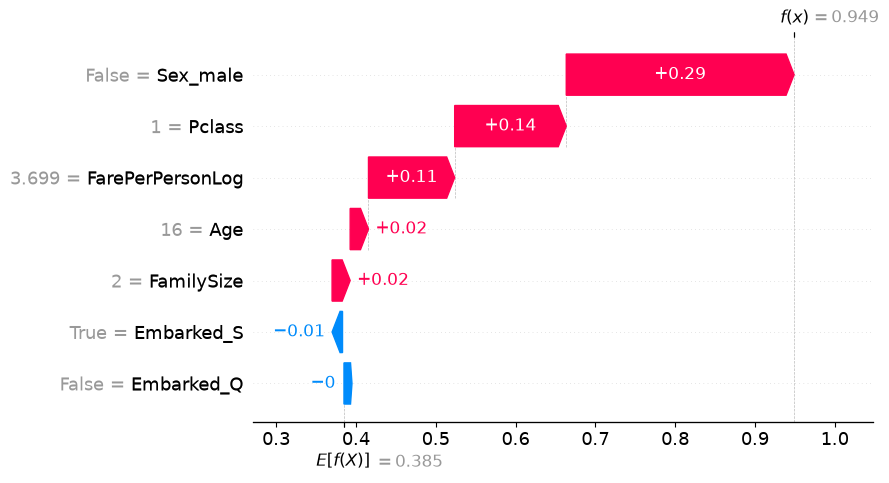

In [ ]:
# Берём пассажира, в котором модель уверена сильнее всего (т.е. почти наверняка выжил)
i = int(np.argmax(proba))
passenger = X_test.iloc[i]
print(f"Пассажир #{X_test.index[i]}: предсказание {proba[i]:.2f}, "
      f"на самом деле {'выжил' if y_test.iloc[i] == 1 else 'погиб'}")
display(passenger.to_frame().T)

exp = shap.Explanation(
    values=shap_values[i],
    base_values=base_value,
    data=passenger.values,
    feature_names=list(X.columns),
)
shap.plots.waterfall(exp)

**4. LIME.** Строит вокруг одного пассажира облако похожих "синтетических" пассажиров, прогоняет их через модель и подгоняет простую линейную модель. Результат — понятные правила вида "Sex_male = 0 повышает шанс". На примере того же пассажира, что и в SHAP.

In [13]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X.columns),
    class_names=["Погиб", "Выжил"],
    mode="classification",
    random_state=42,
)
lime_exp = lime_explainer.explain_instance(passenger.values, rf.predict_proba, num_features=7)

# as_list() возвращает пары (правило, вес); разворот для горизонтального графика
pairs = lime_exp.as_list()[::-1]
rules = [p[0] for p in pairs]
weights = [p[1] for p in pairs]

fig = px.bar(
    x=weights, y=rules, orientation="h",
    text_auto=".3f",
    template="plotly_white", height=350,
    title=f"LIME: почему пассажиру #{X_test.index[i]} предсказано {proba[i]:.2f}",
    labels={"x": "Вес правила (плюс — к «выжил», минус — к «погиб»)", "y": ""}
)
fig.update_traces(marker_color=["#4C78A8" if w > 0 else "#E45756" for w in weights])
fig.update_layout(title_x=0.5, showlegend=False)
fig.show()

c:\Users\Dimi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


| Метод | Вопрос | Когда брать |
|---|---|---|
| Permutation importance | что реально помогает предсказывать на новых данных | отбор признаков |
| SHAP глобально | какие признаки и в какую сторону двигают вероятность | понять модель целиком |
| SHAP локально | почему этому пассажиру дали 0.9 | разбор конкретных предсказаний |
| LIME | то же, но простыми правилами-интервалами | объяснение человеку без ML-фона |

Что помнить:

- Встроенная важность признаков из test2 завышает признаки с большим числом уникальных значений и считается на train — для отбора признаков доверяем permutation importance.
- SHAP и LIME объясняют модель, а не реальность: переобученный шум получит ненулевой вклад.
- SHAP и LIME у одного и того же пассажира обычно согласны по знаку вкладов, но не по величине — у них разная математика; расхождение само по себе полезный сигнал.